# TP Simulación · Sensibilidad de una regla de trading
### Bitcoin simulado con un proceso de Ornstein-Uhlenbeck

Métodos Predictivos Aplicados a las Finanzas – Parte II · UBA · **Giovanni Raffo**

**Consigna (Clase 5, ejercicio propuesto):** simular el mismo conjunto de caminos con φ ± 10 % y σ ± 10 %, comparar el cambio en el Sharpe Ratio y visualizar cómo varía el óptimo en el espacio (π, π̄).

## 1. Datos

Precio de cierre diario de Bitcoin en Yahoo Finance desde enero de 2020, como en la clase. Se trabaja con la variación diaria del precio (en USD), igual que el código de la clase. Las fechas quedan fijas para que el resultado sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

datos = yf.download("BTC-USD", start="2020-01-01", end="2026-09-23", auto_adjust=True, progress=False)
precios = datos["Close"].squeeze().interpolate()
variacion = precios.diff().dropna()
print("Días:", len(variacion))

Días: 2456


## 2. Estimación de φ y σ

Mismo método de la clase: se regresa cada valor contra el anterior, medido desde la media. La pendiente es **φ**: qué parte del desvío respecto de la media se mantiene al día siguiente (cerca de 0, el proceso vuelve a la media enseguida; cerca de 1, vuelve lento). El desvío de los residuos es **σ**, la volatilidad.

In [2]:
x = variacion.values
media = x.mean()
phi = np.polyfit(x[:-1] - media, x[1:], 1)[0]
sigma = np.std(x[1:] - media - phi * (x[:-1] - media))
print("Media:", round(media, 1), "| φ:", round(phi, 4), "| σ:", round(sigma, 1))

Media: 32.2 | φ: -0.0405 | σ: 1520.1


**Lectura:** φ es casi cero: la variación de un día casi no depende de la del día anterior y vuelve a la media enseguida. σ ronda los 1.520 USD por día.

## 3. Grilla de reglas

Cada regla es un par: **π**, el stop-loss (se sale si la pérdida llega a π), y **π̄**, la toma de ganancias (se sale si la ganancia llega a π̄). Como en la clase, 10 valores de cada uno, de 1 a 12 veces σ: 100 reglas. La grilla se arma con el σ estimado y queda fija en todos los escenarios, para poder comparar dónde cae el óptimo.

In [3]:
pis = np.linspace(-12, -1, 10)
pis_bar = np.linspace(1, 12, 10)
print(pis.round(1))
print(pis_bar.round(1))

[-12.  -10.8  -9.6  -8.3  -7.1  -5.9  -4.7  -3.4  -2.2  -1. ]
[ 1.   2.2  3.4  4.7  5.9  7.1  8.3  9.6 10.8 12. ]


## 4. Simulación y evaluación

Se simulan 100.000 caminos de 100 días, partiendo del primer valor de la serie. Los números aleatorios se generan **una sola vez** con semilla fija: así todos los escenarios usan el mismo conjunto de caminos y la diferencia se debe solo al parámetro que cambia.

Para cada regla se recorre cada camino hasta que toca π o π̄ (o hasta el día 100) y se calcula el Sharpe Ratio: ganancia promedio dividida por su desvío.

In [4]:
N, T = 100000, 100
azar = np.random.default_rng(42).standard_normal((N, T - 1))

def simular(phi, sigma):
    caminos = np.empty((N, T))
    caminos[:, 0] = x[0]
    for t in range(1, T):
        caminos[:, t] = media + phi * (caminos[:, t - 1] - media) + sigma * azar[:, t - 1]
    return caminos

def evaluar(caminos):
    ganancia = caminos - caminos[:, [0]]
    filas = []
    for pi in pis:
        for pi_bar in pis_bar:
            sale = (ganancia <= pi * sigma) | (ganancia >= pi_bar * sigma)
            dia = np.where(sale.any(axis=1), sale.argmax(axis=1), T - 1)
            final = ganancia[np.arange(N), dia]
            filas.append([pi, pi_bar, final.mean() / final.std()])
    return pd.DataFrame(filas, columns=["pi", "pi_bar", "sharpe"])

## 5. Caso base

Se simulan los caminos con φ y σ estimados y se busca la regla de mayor Sharpe. En el mapa, cada cuadro es una regla.

pi       -12.000
pi_bar     1.000
sharpe     3.321
Name: 0, dtype: float64


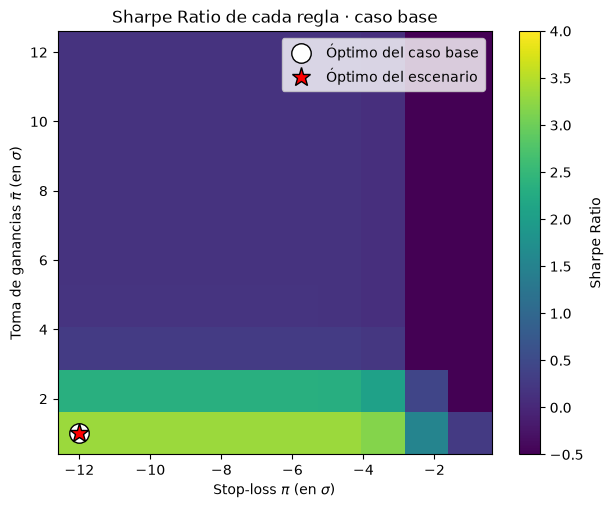

In [5]:
base = evaluar(simular(phi, sigma))
optimo = base.loc[base["sharpe"].idxmax()]
print(optimo.round(3))

def mapa(ax, tabla, titulo):
    grilla = tabla.pivot_table("sharpe", "pi_bar", "pi")
    celdas = ax.pcolormesh(grilla.columns, grilla.index, grilla, shading="nearest", vmin=-0.5, vmax=4)
    mejor = tabla.loc[tabla["sharpe"].idxmax()]
    ax.plot(optimo["pi"], optimo["pi_bar"], "o", color="white", markeredgecolor="black", markersize=14, label="Óptimo del caso base")
    ax.plot(mejor["pi"], mejor["pi_bar"], "*", color="red", markeredgecolor="black", markersize=14, label="Óptimo del escenario")
    ax.set(title=titulo, xlabel=r"Stop-loss $\pi$ (en $\sigma$)", ylabel=r"Toma de ganancias $\bar{\pi}$ (en $\sigma$)")
    return celdas

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.colorbar(mapa(ax, base, "Sharpe Ratio de cada regla · caso base"), label="Sharpe Ratio")
ax.legend()
plt.show()

**Lectura:** la mejor regla es tomar ganancias apenas se gana 1σ, con el stop-loss lejos, en −12σ (Sharpe 3,32, en línea con el 3,30 de la clase). Lo que más pesa es la toma de ganancias: el Sharpe cae rápido al subir π̄. El stop-loss solo importa si está muy cerca (−1σ a −3σ), donde empeora el resultado; más lejos casi nunca se toca.

## 6. Escenarios: φ ± 10 % y σ ± 10 %

Mismos números aleatorios, misma grilla, un parámetro por vez. Por ejemplo, σ +10 % responde a la pregunta: ¿qué pasa si la volatilidad real es 10 % mayor que la estimada?

La tabla muestra la regla óptima de cada escenario y qué le pasa a la regla elegida en el caso base (π = −12σ, π̄ = 1σ).

In [6]:
escenarios = {
    "φ +10 %": (phi * 1.1, sigma),
    "φ −10 %": (phi * 0.9, sigma),
    "σ +10 %": (phi, sigma * 1.1),
    "σ −10 %": (phi, sigma * 0.9),
}
tablas = {"Caso base": base}
for nombre, (f, s) in escenarios.items():
    tablas[nombre] = evaluar(simular(f, s))

filas = []
for nombre, t in tablas.items():
    mejor = t.loc[t["sharpe"].idxmax()]
    regla_base = t.loc[base["sharpe"].idxmax(), "sharpe"]
    cambio = (regla_base / optimo["sharpe"] - 1) * 100
    filas.append([nombre, mejor["pi"], mejor["pi_bar"], mejor["sharpe"], regla_base, cambio])
pd.DataFrame(filas, columns=["Escenario", "π óptimo", "π̄ óptimo", "Sharpe óptimo", "Sharpe regla base", "Cambio (%)"]).round(3)

,Escenario,π óptimo,π̄ óptimo,Sharpe óptimo,Sharpe regla base,Cambio (%)
0,Caso base,-12.0,1.000,3.321,3.321,0.000
1,φ +10 %,-12.0,1.000,3.319,3.319,-0.047
2,φ −10 %,-12.0,1.000,3.323,3.323,0.062
3,σ +10 %,-12.0,2.222,3.694,3.096,-6.770
4,σ −10 %,-12.0,1.000,3.609,3.609,8.667


**Lectura:**
- **φ ± 10 %:** el Sharpe cambia menos de 0,1 % y el óptimo no se mueve. Como φ es casi cero, un error del 10 % sobre él no tiene efecto.
- **σ −10 %:** la regla del caso base sigue siendo la mejor y su Sharpe sube 8,7 % (3,61): con menos volatilidad, la ganancia al salir es más pareja.
- **σ +10 %:** la regla del caso base cae 6,8 % (3,10) y la mejor pasa a ser π̄ = 2,2σ (3,69): con más volatilidad conviene esperar una ganancia mayor.

## 7. Cómo se mueve el óptimo

El círculo blanco es el óptimo del caso base y la estrella roja, el de cada escenario.

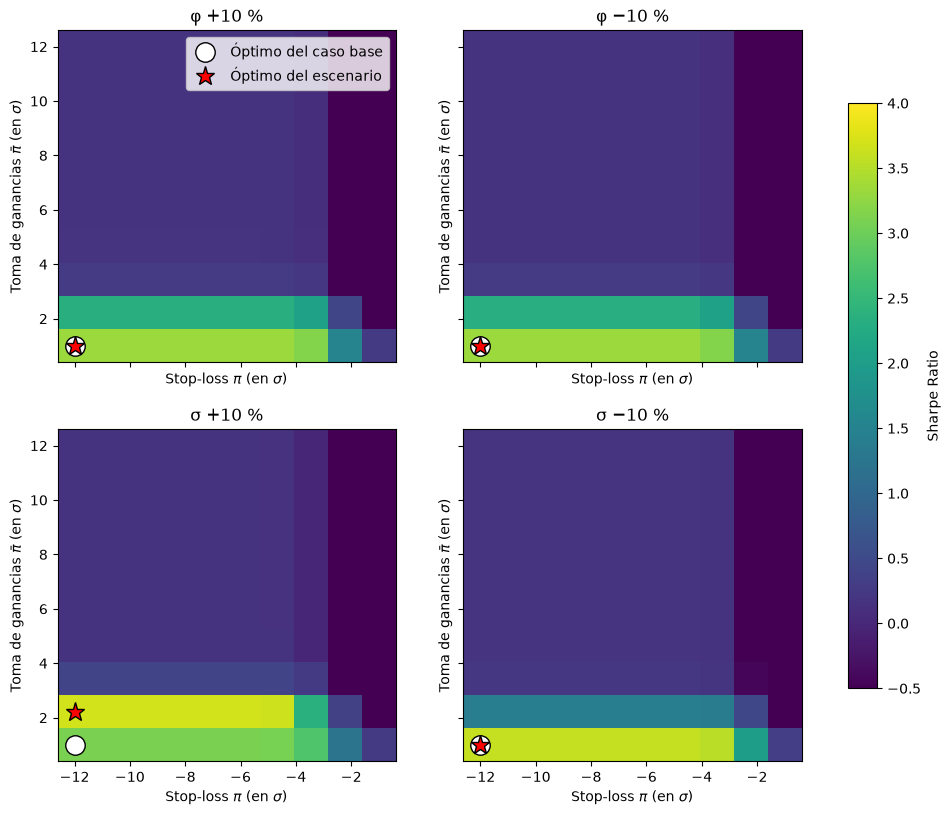

In [7]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 9.5), sharex=True, sharey=True)
for ax, nombre in zip(ejes.flat, escenarios):
    celdas = mapa(ax, tablas[nombre], nombre)
ejes[0, 0].legend()
fig.colorbar(celdas, ax=ejes, label="Sharpe Ratio", shrink=0.8)
plt.show()

**Lectura:** en tres escenarios la estrella queda sobre el círculo: el óptimo no se mueve. Solo con σ +10 % sube un escalón (π̄ de 1σ a 2,2σ). El stop-loss óptimo queda siempre en el extremo, −12σ.

## 8. Cierre

| Punto de la consigna | Qué se hizo |
|---|---|
| Simular el mismo conjunto de caminos | 100.000 caminos de 100 días, mismos números aleatorios en los 5 escenarios |
| φ ± 10 % y σ ± 10 % | Un parámetro por vez, sobre φ = −0,04 y σ = 1.520 USD estimados de Bitcoin |
| Comparar el cambio en el Sharpe Ratio | φ: menos de 0,1 %. σ: −6,8 % con σ +10 % y +8,7 % con σ −10 % |
| Visualizar el óptimo en (π, π̄) | Mapas de las 100 reglas con el óptimo marcado: solo se mueve con σ +10 % |

**Conclusión:** la estrategia es robusta a errores en φ y sensible a errores en σ. El error que más perjudica es subestimar la volatilidad: es el parámetro que hay que estimar con más cuidado.